accuracy: 0.956140350877193

설명 대상 샘플 index: 256
예측 클래스: 0
예측 확률: [1. 0.]

[SHAP 시작]
expected_value: [0.37512088 0.62487912]
SHAP values for one sample:
worst concave points   -0.080586
worst area             -0.076366
worst perimeter        -0.074421
worst radius           -0.059363
mean concave points    -0.056063
mean area              -0.039520
mean radius            -0.036087
area error             -0.035670
mean concavity         -0.033194
mean perimeter         -0.031382
dtype: float64


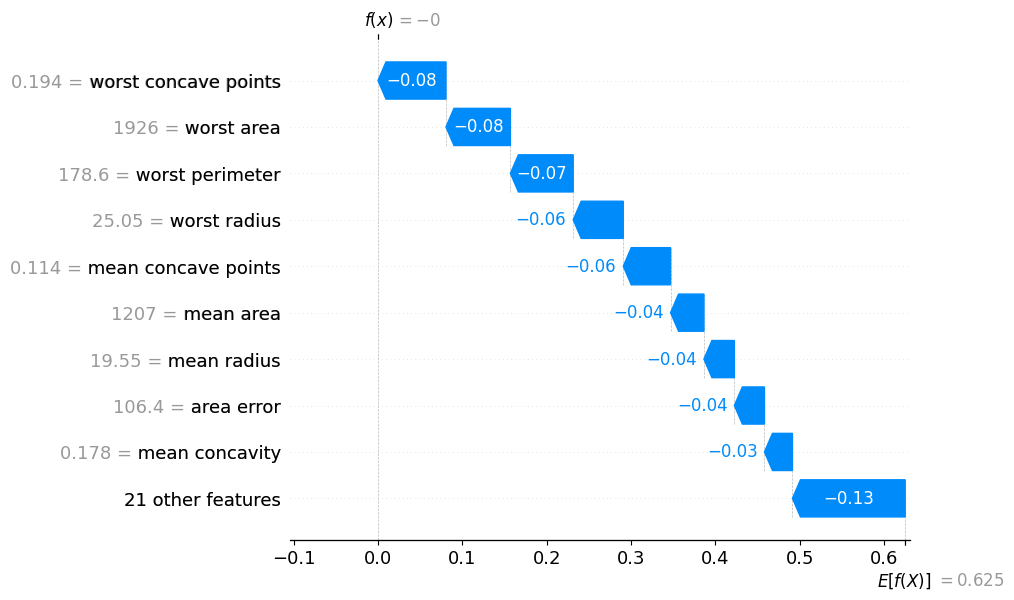

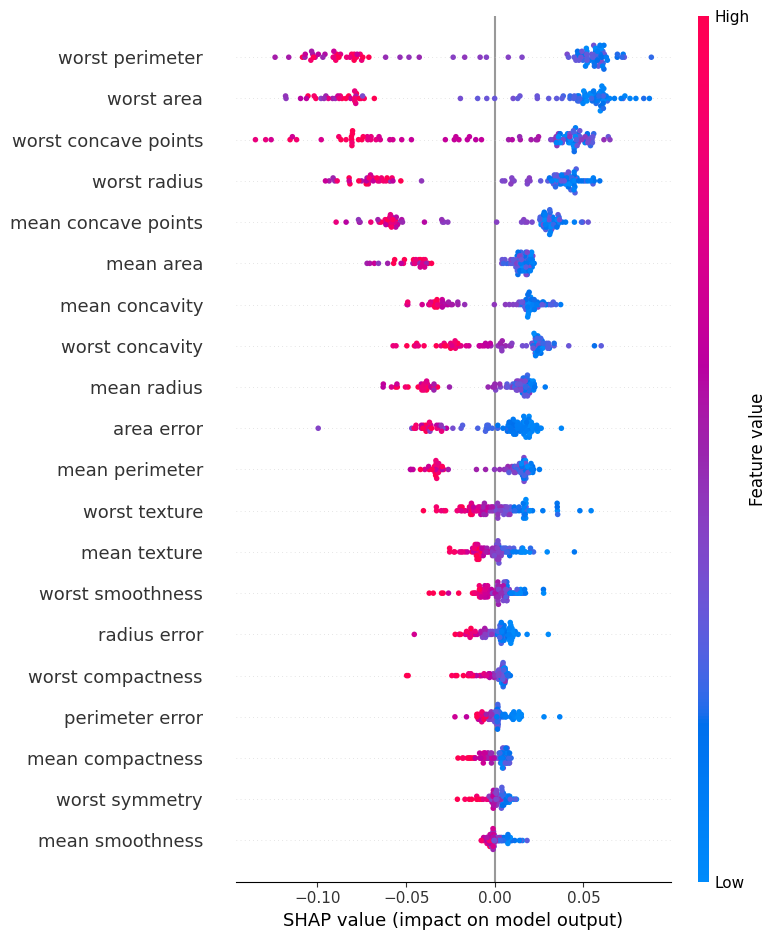


[LIME 시작]

LIME 설명 결과:
('worst area > 1033.50', -0.12628771087519886)
('worst concave points > 0.16', -0.1187831613164658)
('worst radius > 18.55', -0.10750761056022073)
('worst perimeter > 124.95', -0.0999441366862165)
('area error > 44.77', -0.061690632273762445)
('mean concave points > 0.07', -0.05208617880580434)
('worst texture > 29.37', -0.04716147197093591)
('mean area > 770.05', -0.04465235850947391)
('mean radius > 15.74', -0.04011006784603293)
('mean concavity > 0.13', -0.03996969715027282)


/opt/homebrew/Caskroom/miniforge/base/envs/general/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


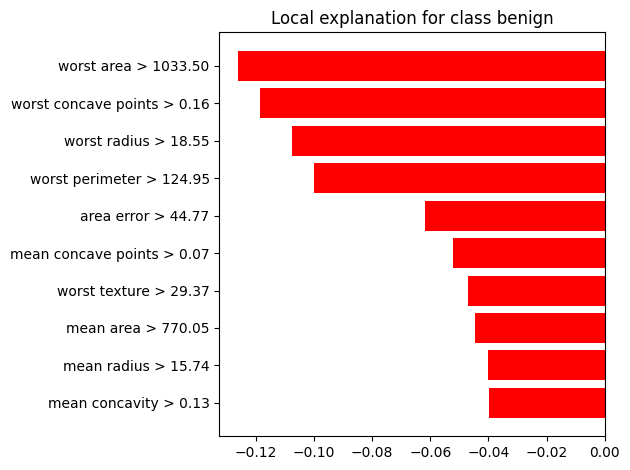

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import shap
from lime.lime_tabular import LimeTabularExplainer


# =========================================
# 1) 데이터 준비
# =========================================
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 2) 모델 학습
# =========================================
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
print("accuracy:", acc)

# 설명할 샘플 1개 선택
idx = 0
x_one = X_test.iloc[[idx]]   # DataFrame 유지
print("\n설명 대상 샘플 index:", X_test.index[idx])
print("예측 클래스:", model.predict(x_one)[0])
print("예측 확률:", model.predict_proba(x_one)[0])


# =========================================
# 3) SHAP
# =========================================
print("\n[SHAP 시작]")

# 트리 모델이라 TreeExplainer 사용
explainer = shap.TreeExplainer(model)

# shap_values 계산
# 최신 shap에서는 multiclass/binary 출력 형태가 버전에 따라 다를 수 있음
shap_values = explainer.shap_values(x_one)

print("expected_value:", explainer.expected_value)

# ---- 버전 호환 처리 ----
# binary classifier에서 shap_values가 list일 수도 있고 ndarray일 수도 있음
if isinstance(shap_values, list):
    # 보통 [class0, class1]
    shap_val_for_plot = shap_values[1]
    expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    # ndarray인 경우 shape 확인
    # 보통 (n_samples, n_features) 또는 (n_samples, n_features, n_classes)
    if len(shap_values.shape) == 2:
        shap_val_for_plot = shap_values
        expected_value = explainer.expected_value
    elif len(shap_values.shape) == 3:
        shap_val_for_plot = shap_values[:, :, 1]
        if isinstance(explainer.expected_value, (list, np.ndarray)):
            expected_value = explainer.expected_value[1]
        else:
            expected_value = explainer.expected_value
    else:
        raise ValueError(f"Unexpected SHAP output shape: {shap_values.shape}")

print("SHAP values for one sample:")
print(pd.Series(shap_val_for_plot[0], index=X.columns).sort_values(key=np.abs, ascending=False).head(10))

# waterfall plot
# shap.Explanation 객체로 감싸주면 버전 호환이 좀 더 나음
try:
    shap_exp = shap.Explanation(
        values=shap_val_for_plot[0],
        base_values=expected_value,
        data=x_one.iloc[0].values,
        feature_names=X.columns.tolist()
    )
    shap.plots.waterfall(shap_exp, max_display=10)
    plt.show()
except Exception as e:
    print("waterfall plot 실패:", e)

# summary plot (테스트셋 일부에 대해)
try:
    x_small = X_test.iloc[:100]
    shap_values_small = explainer.shap_values(x_small)

    if isinstance(shap_values_small, list):
        shap.summary_plot(shap_values_small[1], x_small, show=False)
    else:
        if len(shap_values_small.shape) == 2:
            shap.summary_plot(shap_values_small, x_small, show=False)
        elif len(shap_values_small.shape) == 3:
            shap.summary_plot(shap_values_small[:, :, 1], x_small, show=False)
    plt.show()
except Exception as e:
    print("summary plot 실패:", e)


# =========================================
# 4) LIME
# =========================================
print("\n[LIME 시작]")

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=data.target_names.tolist(),
    mode="classification"
)

lime_exp = lime_explainer.explain_instance(
    data_row=x_one.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=10
)

print("\nLIME 설명 결과:")
for item in lime_exp.as_list():
    print(item)

# matplotlib 시각화
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

[('-0.03 < bmi <= -0.01', -31.079475543841266), ('-0.00 < s5 <= 0.03', 11.9817650512312), ('-0.04 < bp <= -0.01', -7.241230703220614), ('age > 0.04', 5.655871275116489), ('s1 > 0.03', -5.145925562992192), ('sex <= -0.04', 4.126466138988891), ('-0.00 < s4 <= 0.03', 3.4272063206036956), ('-0.01 < s3 <= 0.03', -1.511661795859966)]


/opt/homebrew/Caskroom/miniforge/base/envs/general/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


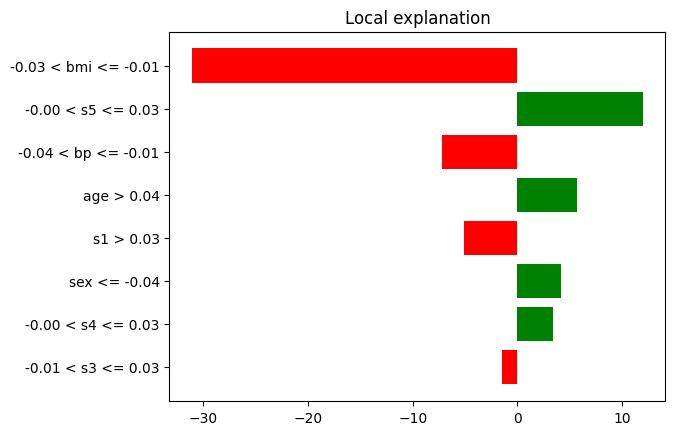

In [4]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from lime.lime_tabular import LimeTabularExplainer

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = RandomForestRegressor(random_state=42, n_estimators=200)
model.fit(X_train, y_train)

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    mode="regression"
)

exp = explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict,
    num_features=8
)

print(exp.as_list())
exp.as_pyplot_figure()
plt.show()